# Bitácora 00 · Bienvenida

**Especialización en Inteligencia Artificial — UPTC**  
Módulo: Aprendizaje por Refuerzo y Sistemas de Recomendación

---

Este notebook existe para demostrar la regla del curso:

> El algoritmo vive en el paquete. El notebook es la bitácora.

Fíjate en que aquí **no se define nada**. Todo se importa de `rlrs`,
que vive en `src/rlrs/` y tiene sus pruebas en `tests/`.
Lo que hacemos aquí es mirar, medir y contar.


In [1]:
from rlrs import GridWorld, RandomPolicy, GreedyTabularPolicy, value_iteration, evaluate
import numpy as np
import matplotlib.pyplot as plt

print('Todo importado correctamente.')


Todo importado correctamente.


## 1. El entorno

Una rejilla 4×5. La meta vale `+1`, la trampa `-1`, y cada paso cuesta `-0.04`
para que al agente le convenga no dar vueltas. Con `noise=0.2`, una de cada
cinco veces el agente se desvía: el suelo resbala.


In [2]:
env = GridWorld()
print(f'{env.n_states} estados · {env.n_actions} acciones · ruido {env.noise}')
print('Muros:', sorted(env.walls))
print('Terminales:', env.terminals)


20 estados · 4 acciones · ruido 0.2
Muros: [(1, 1), (2, 3)]
Terminales: {(0, 4): 1.0, (1, 4): -1.0}


### El modelo del entorno

`transitions(pos, accion)` devuelve la distribución `P(s' | s, a)`.
Esto es lo que la programación dinámica puede usar y lo que los métodos
sin modelo (Q-learning, SARSA) tienen prohibido mirar.


In [3]:
for accion, nombre in enumerate(['arriba','derecha','abajo','izquierda']):
    destinos = env.transitions((3, 1), accion)
    print(f'{nombre:<10}', [(pos, round(p, 2)) for pos, p in destinos])


arriba     [((2, 1), 0.8), ((3, 0), 0.1), ((3, 2), 0.1)]
derecha    [((2, 1), 0.1), ((3, 1), 0.1), ((3, 2), 0.8)]
abajo      [((3, 0), 0.1), ((3, 1), 0.8), ((3, 2), 0.1)]
izquierda  [((2, 1), 0.1), ((3, 0), 0.8), ((3, 1), 0.1)]


## 2. Resolverlo con iteración de valor

Aplicamos la ecuación de optimalidad de Bellman hasta que deja de cambiar:

$$V(s) \leftarrow \max_a \sum_{s'} P(s'|s,a)\,[\,R(s') + \gamma V(s')\,]$$


In [4]:
valores, politica, barridos = value_iteration(env, gamma=0.9)
print(f'Convergió en {barridos} barridos.\n')
print(env.render_values(valores, politica))


Convergió en 35 barridos.

+0.48>  +0.61>  +0.75>  +0.93>   +1    
+0.37^    ###   +0.61^  +0.59^   -1    
+0.28^  +0.36>  +0.47^    ###   +0.10v 
+0.21^  +0.27^  +0.35^  +0.26<  +0.17< 


### Qué pasa si el agente se vuelve miope

Baja `gamma` y vuelve a mirar la fila de abajo. Con un descuento pequeño,
la meta queda tan lejos que deja de compensar el viaje: los valores se
vuelven negativos.

**Ejercicio.** Prueba con `gamma` = 0.55, 0.7, 0.9 y 0.99. ¿Cómo cambia el
número de barridos? ¿Por qué?


In [5]:
for g in (0.55, 0.7, 0.9, 0.99):
    v, _, n = value_iteration(env, gamma=g)
    esquina = v[env.state_index((3, 0))]
    print(f'gamma={g:<5}  barridos={n:>4}  V(esquina inferior izquierda)={esquina:+.3f}')


gamma=0.55   barridos=  21  V(esquina inferior izquierda)=-0.074
gamma=0.7    barridos=  27  V(esquina inferior izquierda)=-0.055
gamma=0.9    barridos=  35  V(esquina inferior izquierda)=+0.206
gamma=0.99   barridos=  51  V(esquina inferior izquierda)=+0.601


## 3. Medir, no confiar

Una corrida no es un resultado. `evaluate` ejecuta muchos episodios con
semillas explícitas y devuelve la media **con su intervalo de confianza**.

La comparación contra la política aleatoria es la comprobación de cordura
del arnés: si la óptima no gana, el problema está en la evaluación.


In [6]:
optima = evaluate(env, GreedyTabularPolicy(politica, name='optima'), episodes=300)
azar   = evaluate(env, RandomPolicy(env.n_actions, seed=0), episodes=300)

for r in (optima, azar):
    print(r)


optima         retorno +0.636 [+0.603, +0.670]  exito 98.0%  pasos   9.1
aleatoria      retorno -2.520 [-2.679, -2.361]  exito 25.7%  pasos  56.8


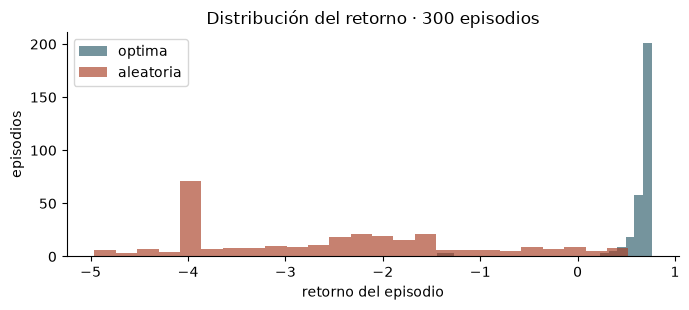

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for r, color in ((optima, '#2C5B69'), (azar, '#A83E24')):
    ax.hist(r.returns, bins=25, alpha=.65, label=r.policy_name, color=color)
ax.set_xlabel('retorno del episodio'); ax.set_ylabel('episodios')
ax.set_title('Distribución del retorno · 300 episodios')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


---

## Tu turno

1. Sube el ruido a `0.5` y vuelve a resolver. ¿Cambia la política cerca de la trampa? ¿Por qué?
2. Cambia `step_reward` a `0.0`. ¿Qué le pasa a la longitud de los episodios? ¿Y por qué tiene sentido?
3. Escribe una política heurística —«ve siempre a la derecha, y si no puedes, sube»— y compárala con las dos anteriores.

**Importante para el punto 3:** esa política es código reutilizable, así que
va en `src/rlrs/policies.py` con su prueba en `tests/`, no en este notebook.
Aquí solo la importas y la mides.
